
Shape: (20000, 18)
Columns: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

Missing values:
Series([], dtype: int64)

Class distribution:
class
GALAXY    11860
STAR       4343
QSO        3797
Name: count, dtype: int64

Encoded classes: {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
 STEP 2 — EXPLORATORY DATA ANALYSIS


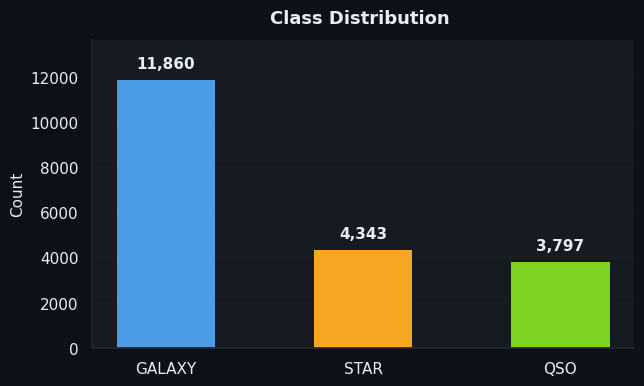

  Saved 01_class_distribution.png


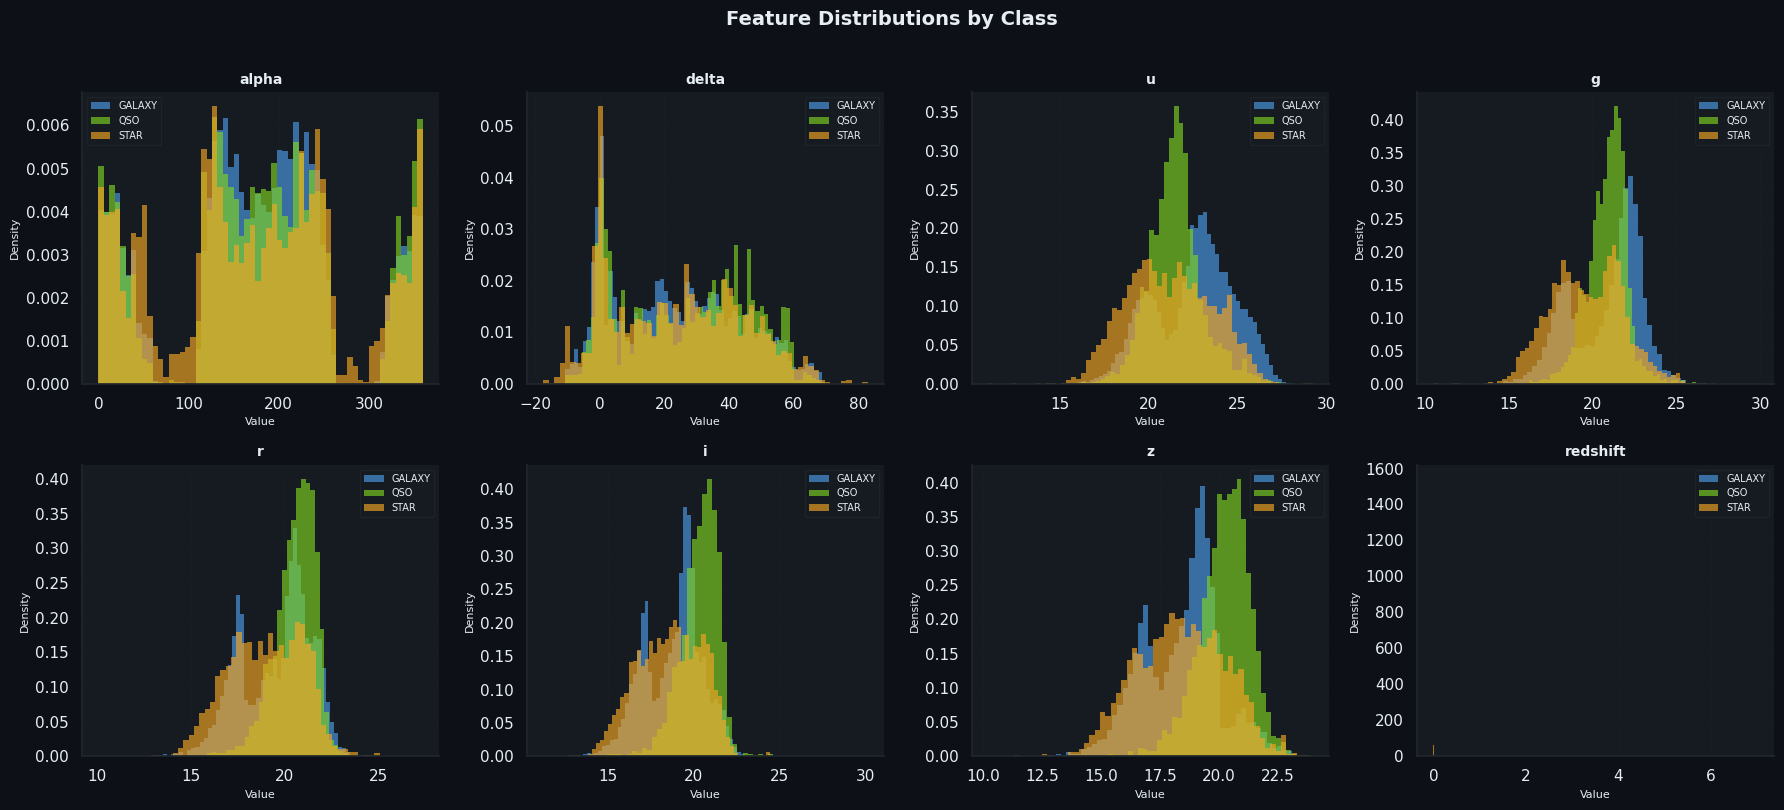

  Saved 02_feature_distributions.png


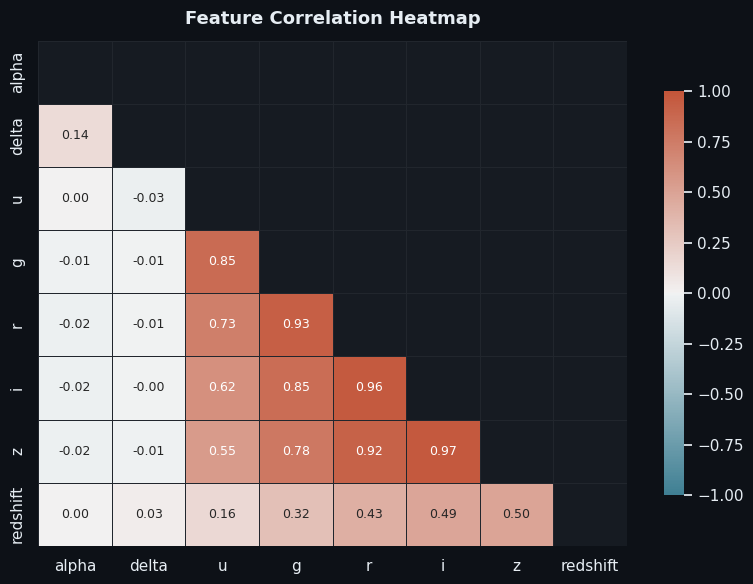

  Saved 03_correlation_heatmap.png


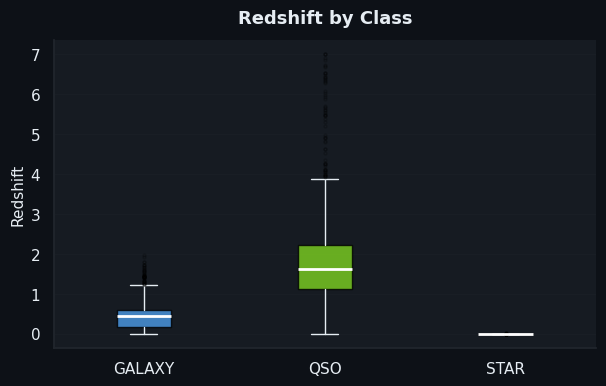

  Saved 04_redshift_boxplot.png
 STEP 3 — PCA VISUALISATION
  Explained variance ratio (PC1+PC2): 70.5%


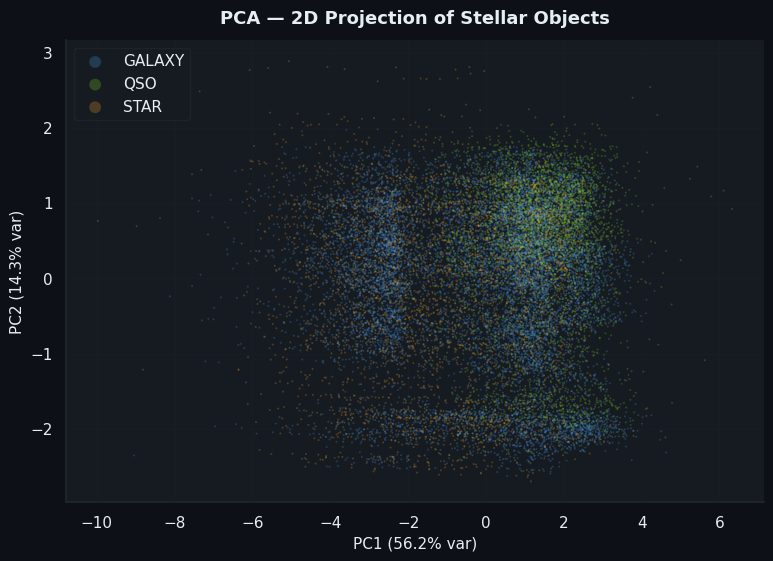

  Saved 05_pca_2d.png


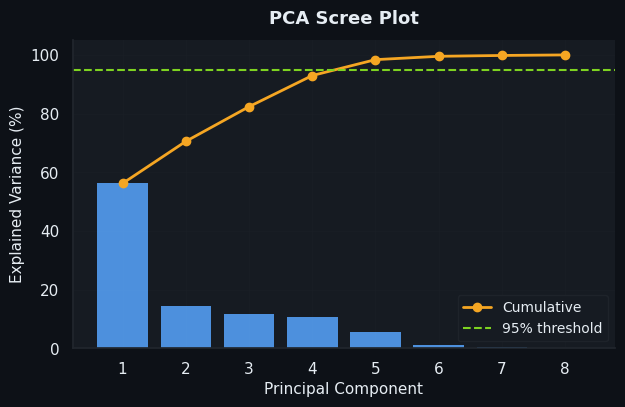

  Saved 06_pca_scree.png
 STEP 4 — TRAIN/TEST SPLIT
  Train: 16,000  |  Test: 4,000
 STEP 5 — RANDOM FOREST WITH GRIDSEARCHCV
  Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

  Random Forest Accuracy : 97.00%
  Macro F1               : 0.9652
 STEP 6 — XGBOOST WITH GRIDSEARCHCV
  Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}

  XGBoost Accuracy       : 97.30%
  Macro F1               : 0.9686

 Best model: XGBoost
 STEP 7 — CONFUSION MATRIX


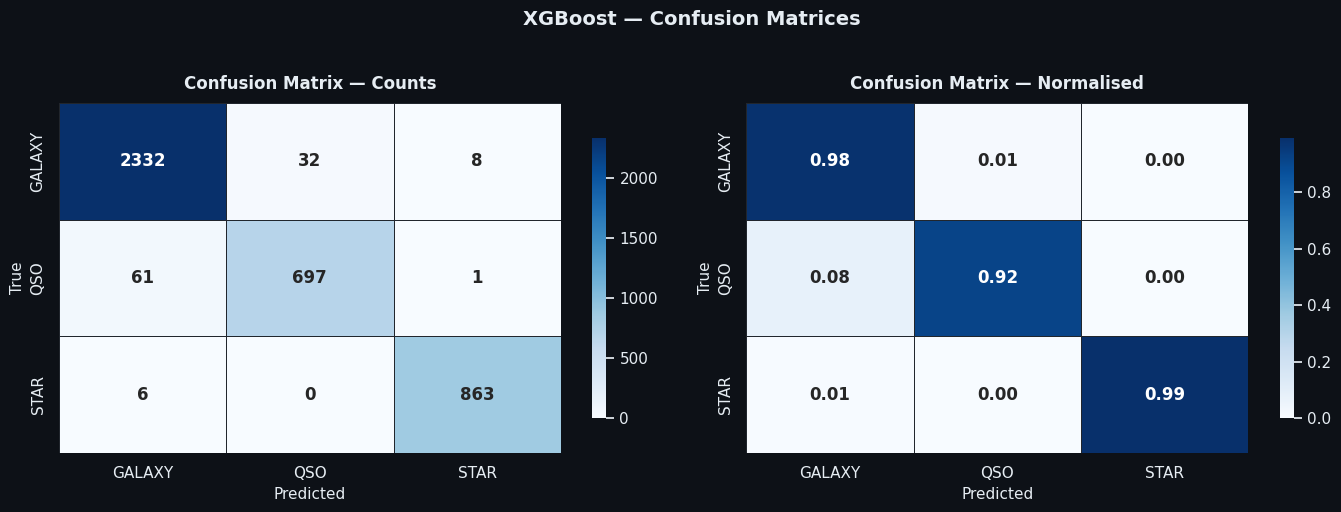

  Saved 07_confusion_matrix.png
 STEP 8 — PER-CLASS PRECISION / RECALL / F1

        precision  recall  f1-score
GALAXY     0.9721  0.9831    0.9776
QSO        0.9561  0.9183    0.9368
STAR       0.9897  0.9931    0.9914


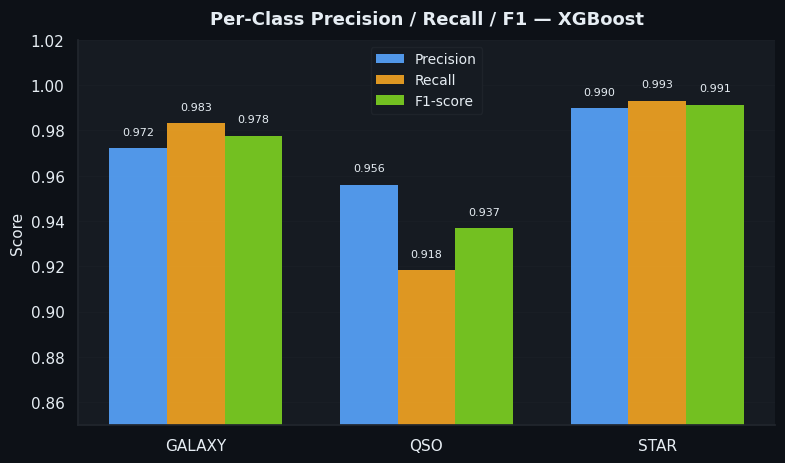

  Saved 08_per_class_metrics.png
 STEP 9 — MULTI-CLASS ROC CURVES
  GALAXY   AUC = 0.9930
  QSO      AUC = 0.9899
  STAR     AUC = 0.9996
  Macro AUC = 0.9942


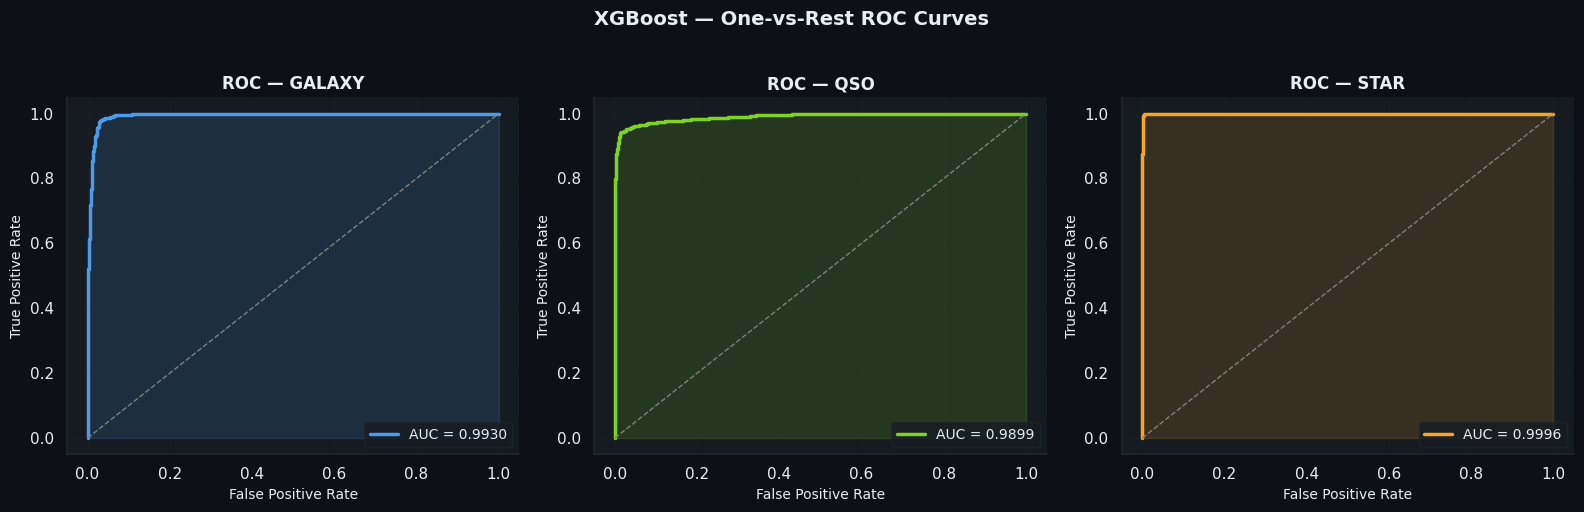

  Saved 09_roc_curves.png
 STEP 10 — FEATURE IMPORTANCES
  Top-5 features: ['redshift', 'g', 'z', 'u', 'i']


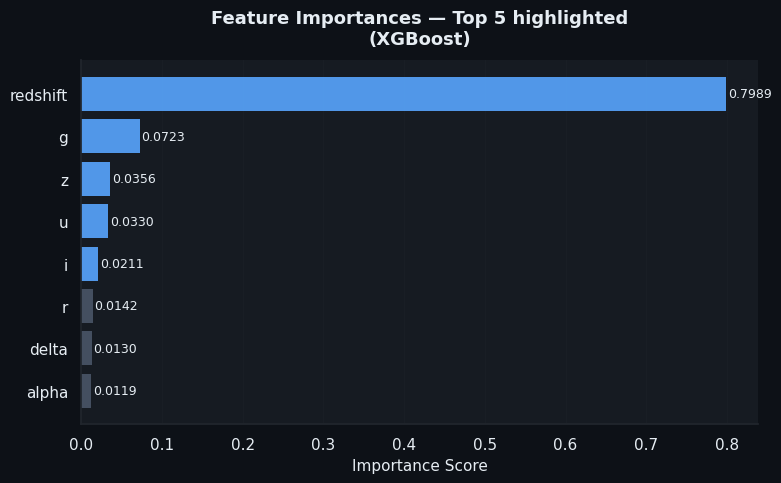

  Saved 10_feature_importances.png
 STEP 11 — MODEL COMPARISON


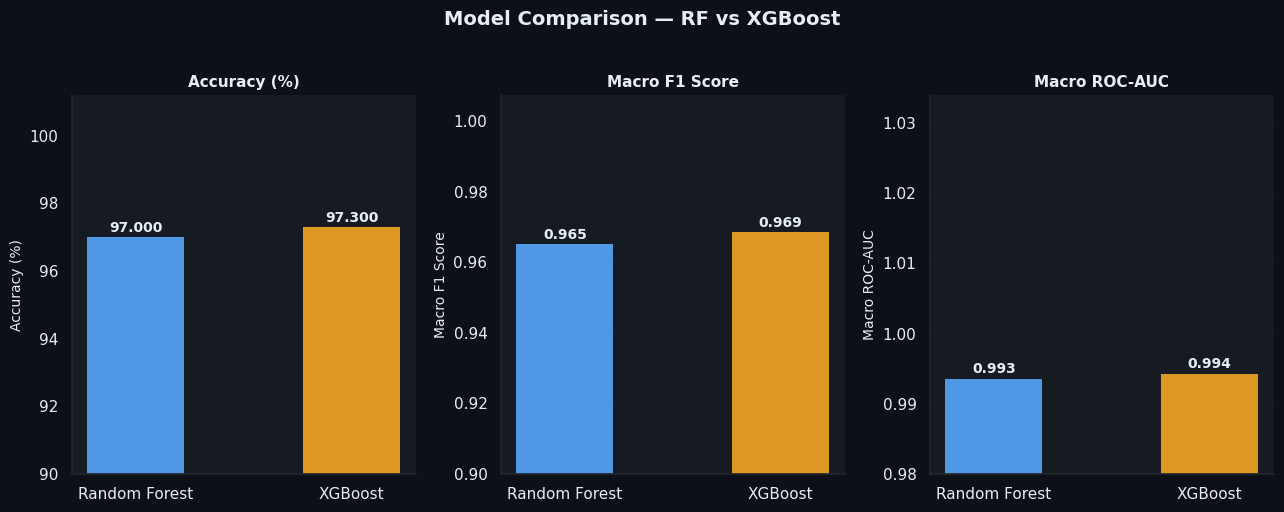

  Saved 11_model_comparison.png
  BEST MODEL  :  XGBoost
    Accuracy    :  97.30%  (target ≥ 93%)
    Macro F1    :  0.9686  (target ≥ 0.92)
    Macro AUC   :  0.9942
    Min Recall  :  0.9183  (all classes ≥ 0.90 ✓ / ✗ : ✓)

All outputs saved to: /content/outputs


In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_fscore_support)
from xgboost import XGBClassifier

import os
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colour palette
COLORS   = {"GALAXY": "#4C9BE8", "STAR": "#F5A623", "QSO": "#7ED321"}
BG       = "#0D1117"
FG       = "#E6EDF3"
GRID_CLR = "#21262D"
ACCENT   = "#58A6FF"
sns.set_theme(style="dark", rc={
    "axes.facecolor": "#161B22", "figure.facecolor": BG,
    "axes.edgecolor": GRID_CLR,  "axes.labelcolor": FG,
    "xtick.color": FG,           "ytick.color": FG,
    "text.color": FG,            "grid.color": GRID_CLR,
    "axes.titlecolor": FG,       "legend.facecolor": "#161B22",
    "legend.edgecolor": GRID_CLR,"font.family": "DejaVu Sans"
})

def save(fig, name):
    path = f"{OUTPUT_DIR}/{name}"
    fig.savefig(path, dpi=150, bbox_inches='tight',
                facecolor=BG, edgecolor='none')
    display(fig)
    plt.close(fig)
    print(f"  {name}")


# 1. LOAD & CLEAN


df = pd.read_csv("star_classification.csv").sample(n=20000, random_state=42)
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
print(f"\nClass distribution:\n{df['class'].value_counts()}")

# Drop irrelevant columns
DROP_COLS = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col',
             'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df.drop(columns=DROP_COLS, inplace=True)

# Feature list (photometric + spectroscopic)
FEATURES  = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
TARGET    = 'class'

X = df[FEATURES].copy()
y = df[TARGET].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)          # GALAXY=0, QSO=1, STAR=2
class_names = le.classes_

print(f"\nEncoded classes: {dict(enumerate(class_names))}")

# 2. EDA PLOTS

print(" STEP 2 — EXPLORATORY DATA ANALYSIS")


class_counts = df[TARGET].value_counts()
cls_colors   = [COLORS[c] for c in class_counts.index]

# 2a. Class Distribution
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
bars = ax.bar(class_counts.index, class_counts.values,
              color=cls_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
            f"{val:,}", ha='center', va='bottom', color=FG, fontsize=11, fontweight='bold')
ax.set_title("Class Distribution ", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Count", fontsize=11)
ax.set_ylim(0, class_counts.max()*1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
save(fig, "01_class_distribution.png")

# 2b. Feature Distributions per Class
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor=BG)
axes = axes.flatten()
for ax, feat in zip(axes, FEATURES):
    for cls in class_names:
        subset = df[df[TARGET]==cls][feat]
        ax.hist(subset, bins=60, alpha=0.65, label=cls,
                color=COLORS[cls], density=True, edgecolor='none')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel("Value", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
    ax.spines[['top','right']].set_visible(False)
fig.suptitle("Feature Distributions by Class", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save(fig, "02_feature_distributions.png")

# 2c. Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, linecolor=GRID_CLR,
            annot_kws={"size": 9}, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
save(fig, "03_correlation_heatmap.png")

# 2d. Redshift Boxplot (most discriminating)
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
data_box = [df[df[TARGET]==c]['redshift'].values for c in class_names]
bp = ax.boxplot(data_box, labels=class_names, patch_artist=True,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color=FG), capprops=dict(color=FG),
                flierprops=dict(marker='o', alpha=0.2, markersize=2))
for patch, cls in zip(bp['boxes'], class_names):
    patch.set_facecolor(COLORS[cls])
    patch.set_alpha(0.8)
ax.set_title("Redshift by Class", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Redshift", fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
save(fig, "04_redshift_boxplot.png")

# 3. PCA VISUALISATION

print(" STEP 3 — PCA VISUALISATION")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"  Explained variance ratio (PC1+PC2): "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
for cls, enc in zip(class_names, range(len(class_names))):
    idx = y_enc == enc
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=COLORS[cls], label=cls, alpha=0.25,
               s=2, edgecolors='none')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=11)
ax.set_title("PCA — 2D Projection of Stellar Objects", fontsize=13, fontweight='bold', pad=12)
lgnd = ax.legend(fontsize=11, markerscale=6)
ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)
save(fig, "05_pca_2d.png")

# Scree plot
pca_full = PCA(random_state=42).fit(X_scaled)
fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.bar(range(1, len(FEATURES)+1),
       pca_full.explained_variance_ratio_*100,
       color=ACCENT, edgecolor='none', alpha=0.85)
ax.plot(range(1, len(FEATURES)+1),
        np.cumsum(pca_full.explained_variance_ratio_)*100,
        color='#F5A623', marker='o', ms=6, lw=2, label='Cumulative')
ax.axhline(95, color='#7ED321', ls='--', lw=1.5, label='95% threshold')
ax.set_xlabel("Principal Component", fontsize=11)
ax.set_ylabel("Explained Variance (%)", fontsize=11)
ax.set_title("PCA Scree Plot", fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.2)
ax.spines[['top','right']].set_visible(False)
save(fig, "06_pca_scree.png")

# 4. TRAIN / TEST SPLIT

print(" STEP 4 — TRAIN/TEST SPLIT")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# 5. RANDOM FOREST — GRIDSEARCHCV

print(" STEP 5 — RANDOM FOREST WITH GRIDSEARCHCV")

rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_cv   = GridSearchCV(rf_base, rf_param_grid, cv=3,
                        scoring='f1_macro', n_jobs=-1, verbose=0)
rf_cv.fit(X_train, y_train)
rf_best = rf_cv.best_estimator_
print(f"  Best params: {rf_cv.best_params_}")

y_pred_rf   = rf_best.predict(X_test)
y_proba_rf  = rf_best.predict_proba(X_test)
rf_acc      = accuracy_score(y_test, y_pred_rf)
rf_report   = classification_report(y_test, y_pred_rf,
                                     target_names=class_names, output_dict=True)
print(f"\n  Random Forest Accuracy : {rf_acc*100:.2f}%")
print(f"  Macro F1               : {rf_report['macro avg']['f1-score']:.4f}")

# 6. XGBOOST — GRIDSEARCHCV

print(" STEP 6 — XGBOOST WITH GRIDSEARCHCV")

xgb_param_grid = {
    'n_estimators':  [200, 300],
    'max_depth':     [6, 8],
    'learning_rate': [0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_base = XGBClassifier(use_label_encoder=False,
                          eval_metric='mlogloss',
                          random_state=42, n_jobs=-1,
                          tree_method='hist')
xgb_cv   = GridSearchCV(xgb_base, xgb_param_grid, cv=3,
                          scoring='f1_macro', n_jobs=-1, verbose=0)
xgb_cv.fit(X_train, y_train)
xgb_best   = xgb_cv.best_estimator_
print(f"  Best params: {xgb_cv.best_params_}")

y_pred_xgb  = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)
xgb_acc     = accuracy_score(y_test, y_pred_xgb)
xgb_report  = classification_report(y_test, y_pred_xgb,
                                      target_names=class_names, output_dict=True)
print(f"\n  XGBoost Accuracy       : {xgb_acc*100:.2f}%")
print(f"  Macro F1               : {xgb_report['macro avg']['f1-score']:.4f}")

# best model
if xgb_acc >= rf_acc:
    best_name, y_pred_best, y_proba_best, best_report = \
        "XGBoost", y_pred_xgb, y_proba_xgb, xgb_report
    best_model = xgb_best
else:
    best_name, y_pred_best, y_proba_best, best_report = \
        "Random Forest", y_pred_rf, y_proba_rf, rf_report
    best_model = rf_best
print(f"\n Best model: {best_name}")


# 7. CONFUSION MATRIX

print(" STEP 7 — CONFUSION MATRIX")

cm      = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ["Confusion Matrix — Counts", "Confusion Matrix — Normalised"],
        ["d", ".2f"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, linecolor=GRID_CLR,
                cbar_kws={"shrink": 0.8},
                annot_kws={"size": 12, "weight": "bold"})
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

fig.suptitle(f"{best_name} — Confusion Matrices", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save(fig, "07_confusion_matrix.png")


# 8. PER-CLASS PRECISION / RECALL / F1

print(" STEP 8 — PER-CLASS PRECISION / RECALL / F1")


metrics_df = pd.DataFrame({
    cls: {m: best_report[cls][m]
          for m in ['precision','recall','f1-score']}
    for cls in class_names
}).T

print(f"\n{metrics_df.round(4)}")

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
x   = np.arange(len(class_names))
w   = 0.25
bar_colors = ['#58A6FF', '#F5A623', '#7ED321']
for i, (metric, color) in enumerate(zip(['precision','recall','f1-score'], bar_colors)):
    vals = metrics_df[metric].values
    bars = ax.bar(x + i*w, vals, w, label=metric.capitalize(),
                  color=color, edgecolor='none', alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}", ha='center', va='bottom', fontsize=8, color=FG)
ax.set_xticks(x + w)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(f"Per-Class Precision / Recall / F1 — {best_name}", fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
save(fig, "08_per_class_metrics.png")


# 9. ROC CURVES (ONE-VS-REST)

print(" STEP 9 — MULTI-CLASS ROC CURVES")
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
auc_scores = {}
for ax, cls, enc in zip(axes, class_names, range(len(class_names))):
    y_bin   = (y_test == enc).astype(int)
    y_score = y_proba_best[:, enc]
    fpr, tpr, _ = roc_curve(y_bin, y_score)
    auc          = roc_auc_score(y_bin, y_score)
    auc_scores[cls] = auc
    ax.plot(fpr, tpr, color=COLORS[cls], lw=2.5,
            label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1], color='gray', ls='--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.15, color=COLORS[cls])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(f"ROC — {cls}", fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.2)
    ax.spines[['top','right']].set_visible(False)
    print(f"  {cls:<8} AUC = {auc:.4f}")

macro_auc = np.mean(list(auc_scores.values()))
print(f"  Macro AUC = {macro_auc:.4f}")
fig.suptitle(f"{best_name} — One-vs-Rest ROC Curves", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save(fig, "09_roc_curves.png")


# 10. FEATURE IMPORTANCES
print(" STEP 10 — FEATURE IMPORTANCES")
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = rf_best.feature_importances_

imp_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=True)
top5   = imp_df.tail(5)['feature'].tolist()
print(f"  Top-5 features: {top5[::-1]}")

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
colors_bar = [ACCENT if f in top5 else '#4A5568' for f in imp_df['feature']]
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=colors_bar, edgecolor='none', alpha=0.9)
for bar, val in zip(bars, imp_df['importance']):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9, color=FG)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title(f"Feature Importances — Top 5 highlighted\n({best_name})",
             fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
save(fig, "10_feature_importances.png")


# 11. MODEL COMPARISON SUMMARY CHART

print(" STEP 11 — MODEL COMPARISON")
models      = ['Random Forest', 'XGBoost']
accuracies  = [rf_acc*100, xgb_acc*100]
f1_macros   = [rf_report['macro avg']['f1-score'],
               xgb_report['macro avg']['f1-score']]
roc_aucs    = []
for y_pred_m, y_proba_m in [(y_pred_rf, y_proba_rf),
                              (y_pred_xgb, y_proba_xgb)]:
    aucs = []
    for enc in range(len(class_names)):
        y_bin   = (y_test == enc).astype(int)
        aucs.append(roc_auc_score(y_bin, y_proba_m[:, enc]))
    roc_aucs.append(np.mean(aucs))

fig, axes = plt.subplots(1, 3, figsize=(13, 5), facecolor=BG)
for ax, vals, title, ymin in zip(
        axes,
        [accuracies, f1_macros, roc_aucs],
        ['Accuracy (%)', 'Macro F1 Score', 'Macro ROC-AUC'],
        [90, 0.90, 0.98]):
    bar_c = [ACCENT, '#F5A623']
    bars = ax.bar(models, vals, color=bar_c, edgecolor='none',
                  width=0.45, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005*max(vals),
                f"{v:.3f}", ha='center', va='bottom', fontsize=10,
                fontweight='bold', color=FG)
    ax.set_ylim(ymin, max(vals)*1.04)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
fig.suptitle("Model Comparison — RF vs XGBoost", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save(fig, "11_model_comparison.png")


# FINAL SUMMARY

print(f"  BEST MODEL  :  {best_name}")
print(f"    Accuracy    :  {max(rf_acc,xgb_acc)*100:.2f}%  (target ≥ 93%)")
print(f"    Macro F1    :  {max(rf_report['macro avg']['f1-score'], xgb_report['macro avg']['f1-score']):.4f}  (target ≥ 0.92)")
print(f"    Macro AUC   :  {max(roc_aucs):.4f}")
min_recall = min(best_report[c]['recall'] for c in class_names)
print(f"    Min Recall  :  {min_recall:.4f}  (all classes ≥ 0.90 ✓ / ✗ : {'✓' if min_recall>=0.90 else '✗'})")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")

